# GDSFactory PDK MMI: one-pulse 3D S-parameter spectrum

Import a PDK MMI and its active layer stack into BeamZ, inspect the source mode, launch one forward Gaussian pulse, visualize field and power flow in the silicon `xy` plane, and recover the `o1` input-column spectrum (`S11`, `S21`, and `S31`) at 11 frequencies.

## Goal

Use one reproducible 3D FDTD run. Frequency-domain monitors accumulate the broadband pulse at every port. The isolated input uses modal decomposition for reflection; the two closely spaced outputs use non-overlapping Poynting-flux apertures for power-wave transmission magnitudes.

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import gdsfactory as gf
import jax

try:
    from IPython.display import display
except ImportError:
    display = print

import beamz
from beamz.analysis import mode_data_to_dataframe, s_parameters
from beamz.analysis.data import analysis_inputs
from beamz.analysis.plotting import (
    _dft_plane_components,
    _monitor_plane_shape_and_coords,
    plot_mode_field_components,
)
from beamz.const import LIGHT_SPEED
from beamz.design.gdsfactory import Settings, prepare
from beamz.design.grid_spec import GridSpec
from beamz.simulation.backend import resolve_backend

test_mode = os.environ.get("BEAMZ_DOCS_TEST") == "1"
jax_backend = jax.default_backend()
execution_backend = resolve_backend("cuda_streamed")

Python: /home/quentinwach/.cache/uv/builds-v0/.tmpGjO8ad/bin/python
BeamZ: 0.5.0 (/tmp/beamz-gdsfactory-v05/beamz/__init__.py)
JAX setup backend: gpu | devices: [CudaDevice(id=0)]
FDTD backend: cuda_streamed (direct CUDA streaming)


## 1. Select the PDK building block

In [2]:
# Activate the bundled generic PDK explicitly. GDSFactory 8 did this on
# import, while newer releases require activation before component creation.
try:
    active_pdk = gf.get_active_pdk()
except ValueError:
    gf.gpdk.PDK.activate()
    active_pdk = gf.get_active_pdk()
layer_stack = active_pdk.get_layer_stack()
mmi = gf.components.mmi1x2()

print(f"Active PDK: {active_pdk.name}")
print(f"Component: {mmi.name}")
print("Optical ports:", [port.name for port in mmi.ports])

Active PDK: generic
Component: mmi1x2_WNone_WT1_LT10_L_4e0f7121
Optical ports: ['o1', 'o2', 'o3']


### Plot the GDS layout

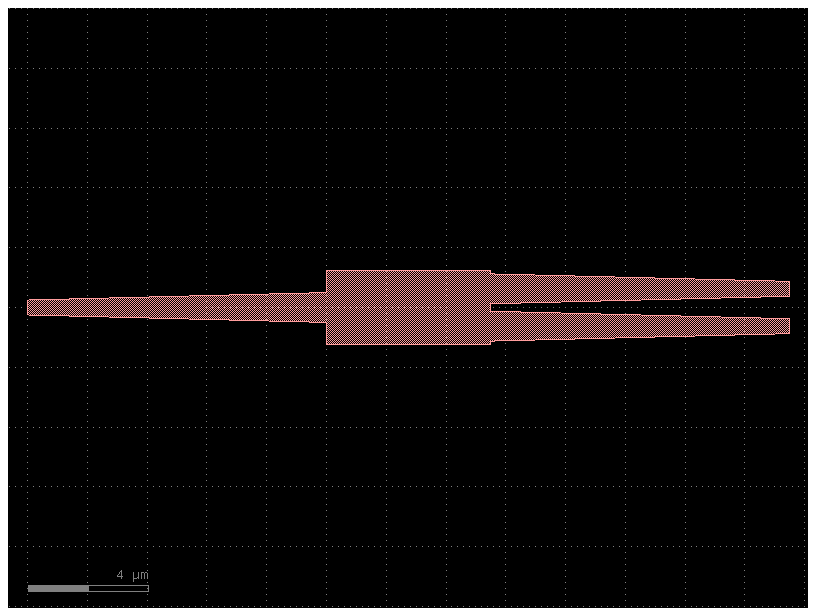

In [3]:
mmi.plot()
plt.show()

## 2. Define stack and numerical settings

In [4]:
material_map = {
    "si": 3.48**2,
    "sio2": 1.44**2,
    "air": 1.0,
}

settings = Settings(
    n_core=3.48,
    n_clad=1.44,
    wavelengths=(1.50e-6, 1.60e-6),
    wavelength_points=3 if test_mode else 11,
    xy_padding=0.5e-6 if test_mode else 2.0e-6,
    z_padding=0.25e-6,
    pml_thickness=1.0e-6,
    run_time=(8.0 / (LIGHT_SPEED / 1.55e-6)) if test_mode else 1.2e-12,
    grid_spec=GridSpec.auto(
        wavelength=1.55e-6,
        min_steps_per_wvl=4 if test_mode else 15,
        max_scale=1.25,
    ),
)

### Import the stack-aware 3D geometry

In [5]:
setup = prepare(
    mmi,
    layer_stack=layer_stack,
    material_map=material_map,
    settings=settings,
)

# print out the port data
for port in setup.port_metadata:
    print(
        f"{port.name}: outward={port.outward_direction}, "
        f"inward={port.inward_direction}, axis={port.axis}"
    )

o1: outward=-x, inward=+x, axis=x
o2: outward=+x, inward=-x, axis=x
o3: outward=+x, inward=-x, axis=x


## 3. Configure the source and DFT monitors

In [6]:
prepared_ports = {port.name: port for port in setup.ports}
mode_spec = beamz.ModeSpec(
    num_modes=1,
    mode_index=0,
    target_neff=0.98 * settings.n_core,
    polarization="te",
)

# Use a centered, compact aperture: 2.0 µm wide by 1.5 µm high.
source_port = prepared_ports["o1"].updated_copy(
    size=(0.0, 2.0e-6, 1.5e-6),
    mode_spec=mode_spec,
    monitor_name="mode_o1",
)
source = source_port.to_source(
    settings.center_frequency,
    settings.frequency_width,
)

# Output flux apertures stay below the 1.25 µm guide separation so they do not
# count the neighboring output. All monitors are broadband DFT acquisitions.
power_ports = {
    name: port.updated_copy(size=(0.0, 1.0e-6, 2.0e-6), mode_spec=mode_spec)
    for name, port in prepared_ports.items()
}
power_monitors = tuple(
    beamz.FluxMonitor(
        center=power_ports[name].center,
        size=power_ports[name].size,
        freqs=settings.frequencies,
        name=f"power_{name}",
    )
    for name in ("o1", "o2", "o3")
)
input_mode_monitor = source_port.to_monitor(settings.frequencies)

core_z = prepared_ports["o1"].center[2]
field_xy = beamz.FieldMonitor(
    center=(0.5 * setup.design.width, 0.5 * setup.design.height, core_z),
    size=(setup.design.width, setup.design.height, 0.0),
    freqs=[settings.center_frequency],
    fields=("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"),
    name="field_xy",
)

## 4. Build and preview the 3D simulation

In [7]:
simulation = beamz.Simulation(
    design=setup.design,
    sources=(source,),
    monitors=(*power_monitors, input_mode_monitor, field_xy),
    boundaries=(beamz.PML(thickness=settings.pml_thickness, formulation="cpml"),),
    grid_spec=settings.grid_spec,
    run_time=settings.run_time,
    setup_device="default",
)

print(f"3D grid: {simulation.grid.shape} | steps: {simulation.num_steps}")
print("Source: one +x Gaussian pulse at o1")
print(f"JAX setup backend: {jax_backend}")
print(f"FDTD backend: {execution_backend} (direct CUDA streaming)")

3D grid: (994, 145, 99) | steps: 21845
Source: one +x Gaussian pulse at o1
JAX setup backend: gpu
FDTD backend: cuda_streamed (direct CUDA streaming)


### Plot material cross sections and device placement

Use BeamZ's public cross-section plotter for the silicon-core `xy` plane and device-center `xz` plane. It renders the material stack, CPML regions, and finite source/DFT-monitor planes without compiling or exposing the FDTD mesh.

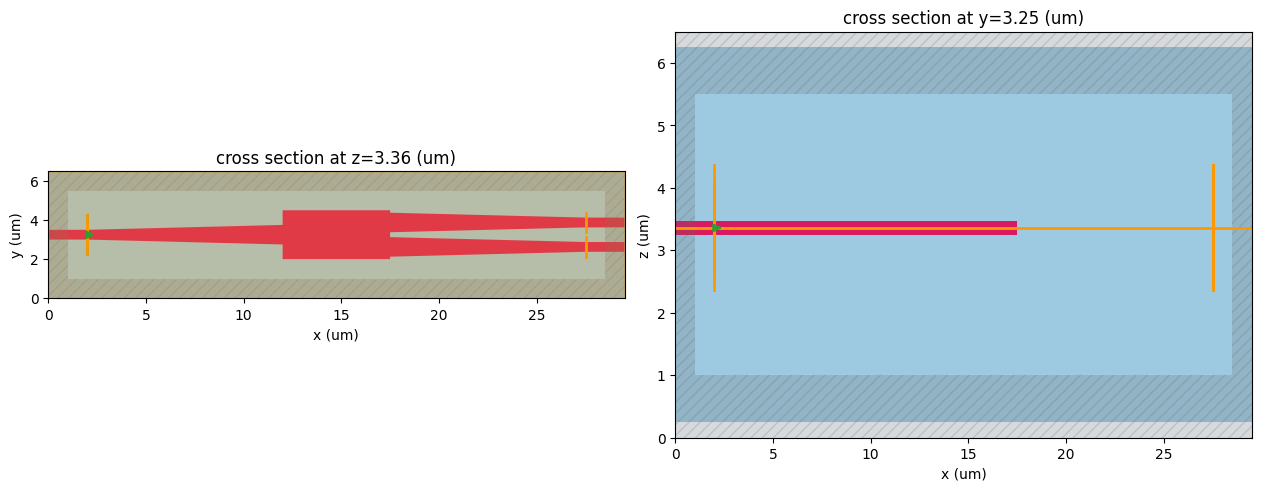

In [8]:
# Use BeamZ's public layout plotter. It renders antialiased 3D material
# cross sections, CPML bands, and finite source/monitor planes without
# compiling or displaying the FDTD mesh.
fig, axes = simulation.plot(
    z=core_z,
    y=0.5 * setup.design.height,
    figsize=(12.5, 4.8),
    width_ratios=(1.0, 1.0),
    source_markers=True,
    monitor_markers=True,
    show=False,
)
for axis in np.asarray(axes).flat: axis.grid(False)
plt.show()

## 5. Solve the source mode

In [9]:
source_modes = source.solve_modes(
    simulation,
    freqs=[settings.center_frequency],
)
display(mode_data_to_dataframe(source_modes))

,,wavelength,n eff,k eff,loss (dB/cm),mode area
f,mode_index,,,,,
1.934951e+14,0,1.549355,2.469561,0.0,0.0,0.158424


### Plot source-mode components

Arrange the six electromagnetic components in a compact 2×3 panel: electric fields on the first row and magnetic fields on the second.

/tmp/beamz-gdsfactory-v05/beamz/analysis/plotting.py:2321: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


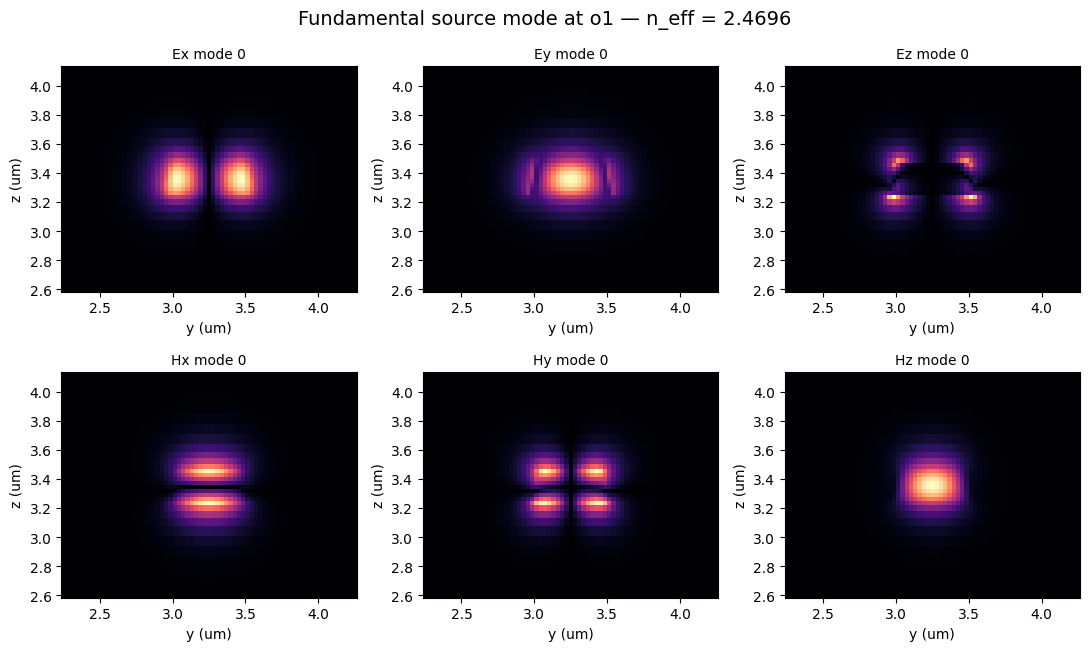

In [10]:
mode_figure, mode_axes = plt.subplots(2, 3, figsize=(11, 6.6), constrained_layout=True)
mode_figure, mode_axes, source_neffs = plot_mode_field_components(
    source_modes,
    field_names=("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"),
    mode_indices=(0,),
    val="abs",
    f=settings.center_frequency,
    ax=mode_axes,
    show=False,
)
for axis in np.asarray(mode_axes).flat:
    axis.grid(False)
    axis.set_title(axis.get_title().split(", n_eff=")[0], fontsize=10)
mode_figure.suptitle(
    f"Fundamental source mode at o1 — n_eff = {np.real(source_neffs[0]):.4f}",
    fontsize=14,
)
plt.show()

## 6. Run the single-pulse simulation

In [11]:
# Compile once through the public API. JAX setup/mode work runs on CUDA, and
# time stepping uses BeamZ's direct CUDA streaming backend.
program = simulation.compile(
    num_steps=simulation.num_steps,
    backend=execution_backend,
)

results = simulation.run(progress=True, backend=execution_backend)

* Compiling simulation...

* Running simulation: [--------------------] 0% (0/21845 steps)

* Running simulation: [#-------------------] 5% (1093/21845 steps)

* Running simulation: [##------------------] 10% (2186/21845 steps)

* Running simulation: [###-----------------] 15% (3279/21845 steps)

...

* Running simulation: [#################---] 85% (18581/21845 steps)

* Running simulation: [##################--] 90% (19674/21845 steps)

* Running simulation: [###################-] 95% (20767/21845 steps)

* Running simulation: [####################] 100% (21845/21845 steps)

Simulation runtime: 62.28 s
GCUPS: 5.005


## 7. Plot the field through the MMI

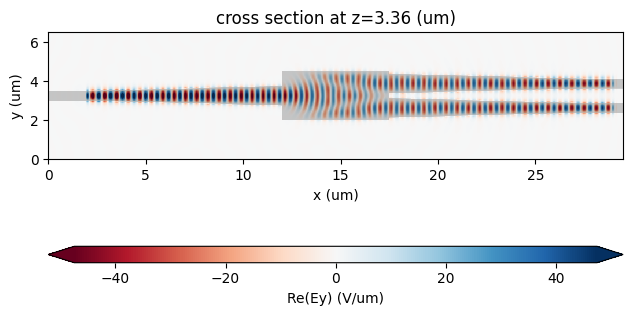

In [12]:
results.plot_field(
    "field_xy",
    "Ey",
    frequency=settings.center_frequency,
    val="real",
    cmap="RdBu",
    show_grid=False,
)
plt.show()

## 8. Compute pulse-integrated power flow in the xy plane

In [13]:
field_data = analysis_inputs(results)["field_xy"]
frequency_index = int(
    np.argmin(np.abs(np.asarray(field_data.frequencies) - settings.center_frequency))
)
plane_shape, _, _, sample_region = _monitor_plane_shape_and_coords(
    field_data.coordinates,
    field_data.monitor_geometry,
)

field_planes = {
    component: _dft_plane_components(
        field_data, component, frequency_index, plane_shape
    )[0][0]
    for component in ("Ex", "Ey", "Ez", "Hx", "Hy", "Hz")
}
selected_frequency = float(field_data.frequencies[frequency_index])
magnetic_phase = np.exp(-1j * np.pi * selected_frequency * field_data.dt)
hx = field_planes["Hx"] * magnetic_phase
hy = field_planes["Hy"] * magnetic_phase
hz = field_planes["Hz"] * magnetic_phase
sx = 0.5 * np.real(
    field_planes["Ey"] * np.conjugate(hz)
    - field_planes["Ez"] * np.conjugate(hy)
)
sy = 0.5 * np.real(
    field_planes["Ez"] * np.conjugate(hx)
    - field_planes["Ex"] * np.conjugate(hz)
)
in_plane_power_density = np.sqrt(sx**2 + sy**2)
power_reference = max(float(np.nanmax(in_plane_power_density)), 1e-30)
power_density_db = 10.0 * np.log10(
    np.maximum(in_plane_power_density / power_reference, 1e-4)
)

grid = field_data.coordinates.grid
x_interval = sample_region.axis_interval("x")
y_interval = sample_region.axis_interval("y")
x_edges_um = grid.axis_edges("x")[x_interval.start : x_interval.stop + 1] * 1e6
y_edges_um = grid.axis_edges("y")[y_interval.start : y_interval.stop + 1] * 1e6

### Plot the spatial power-flow map

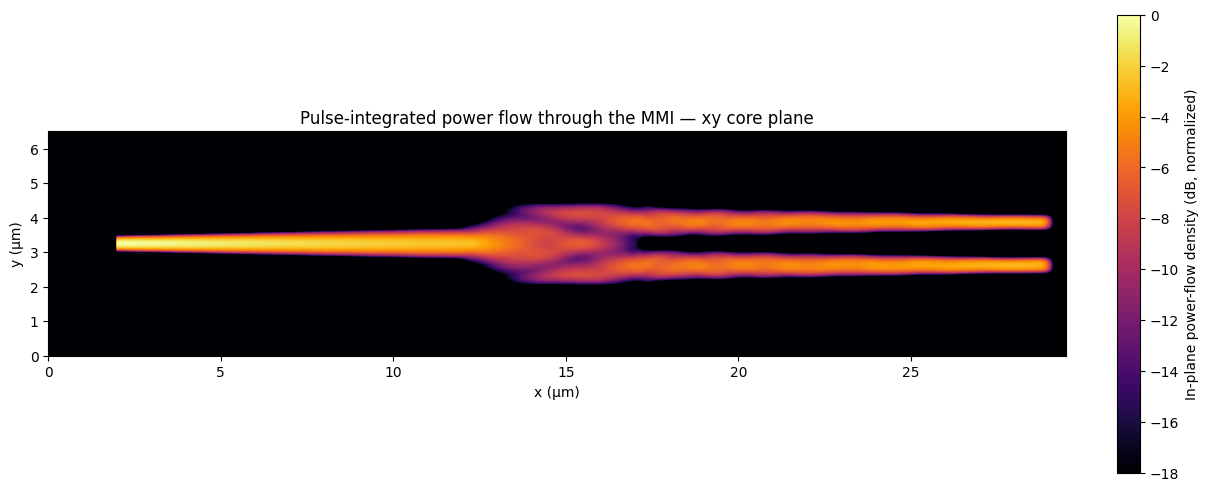

In [14]:
fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
power_image = ax.pcolormesh(
    x_edges_um,
    y_edges_um,
    power_density_db,
    shading="flat",
    cmap="inferno",
    vmin=-18.0,
    vmax=0.0,
)
fig.colorbar(power_image, ax=ax, label="In-plane power-flow density (dB, normalized)")
ax.set(
    xlabel="x (µm)",
    ylabel="y (µm)",
    title="Pulse-integrated power flow through the MMI — xy core plane",
)
ax.set_aspect("equal")
ax.grid(False)
plt.show()

## 9. Extract and plot the broadband S-parameter magnitudes

In [15]:
# S11 comes from the input modal DFT decomposition.
reflection = s_parameters(
    results,
    source_port=source_port,
    ports=(source_port,),
    output_ports=(source_port,),
    frequencies=settings.frequencies,
)
s11 = np.asarray(reflection.s_matrix[("o1", "o1")], dtype=np.complex128)
launched_power = float(results.launched_power())
assert launched_power > 0.0

# The two output DFT planes are non-overlapping. Their power ratios give the
# conventional 20 log10|S| = 10 log10(Pout/Pin) magnitude spectra.
output_flux = {
    name: np.maximum(np.asarray(results[f"power_{name}"].flux, dtype=float), 0.0)
    for name in ("o2", "o3")
}
s21_magnitude = np.sqrt(output_flux["o2"] / launched_power)
s31_magnitude = np.sqrt(output_flux["o3"] / launched_power)

spectra_db = {
    "S11": 20.0 * np.log10(np.maximum(np.abs(s11), 1e-12)),
    "S21": 20.0 * np.log10(np.maximum(s21_magnitude, 1e-12)),
    "S31": 20.0 * np.log10(np.maximum(s31_magnitude, 1e-12)),
}
wavelengths_um = LIGHT_SPEED / settings.frequencies * 1e6

### Plot S11, S21, and S31

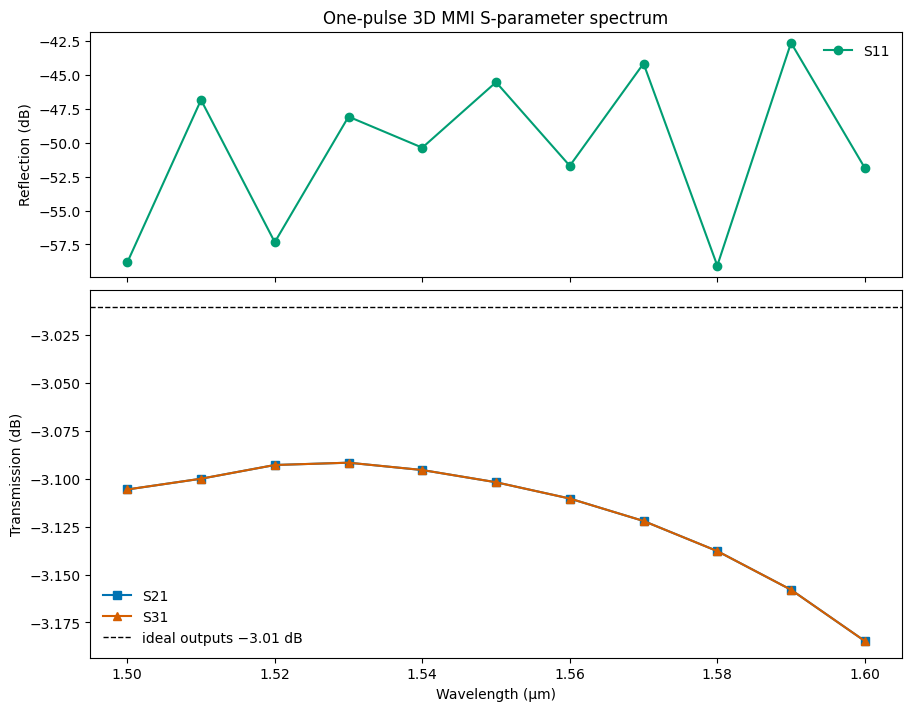

Nearest DFT wavelength: 1.550000 µm
S11 at 1.550000 µm: -45.548 dB
S21 at 1.550000 µm: -3.102 dB
S31 at 1.550000 µm: -3.102 dB
Output imbalance at center: 0.000 dB


In [16]:
order = np.argsort(wavelengths_um)
fig, axes = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": (0.8, 1.2)},
)
axes[0].plot(
    wavelengths_um[order], spectra_db["S11"][order], "o-",
    color="#009E73", label="S11",
)
axes[1].plot(
    wavelengths_um[order], spectra_db["S21"][order], "s-",
    color="#0072B2", label="S21",
)
axes[1].plot(
    wavelengths_um[order], spectra_db["S31"][order], "^-",
    color="#D55E00", label="S31",
)
axes[1].axhline(
    -3.0103, color="black", ls="--", lw=1, label="ideal outputs −3.01 dB"
)
axes[0].set(ylabel="Reflection (dB)", title="One-pulse 3D MMI S-parameter spectrum")
axes[1].set(xlabel="Wavelength (µm)", ylabel="Transmission (dB)")
for axis in axes:
    axis.legend(frameon=False)
    axis.grid(False)
plt.show()

center = int(np.argmin(np.abs(wavelengths_um - 1.55)))
print(f"Nearest DFT wavelength: {wavelengths_um[center]:.6f} µm")
for name in ("S11", "S21", "S31"):
    print(f"{name} at {wavelengths_um[center]:.6f} µm: {spectra_db[name][center]:.3f} dB")
print(
    "Output imbalance at center: "
    f"{abs(spectra_db['S21'][center] - spectra_db['S31'][center]):.3f} dB"
)

## Checks and interpretation

The mode panels verify the launched mode, the `Ey` and Poynting maps show field and power propagation through the physical 3D splitter, and the final chart uses 11 DFT frequencies accumulated during the same Gaussian-pulse run. `S11` is a complex modal reflection coefficient. Because the two output guides are too close for independent wide-aperture mode solves, `S21` and `S31` are reported as power-wave magnitudes from isolated flux apertures; their phases are intentionally not invented.